# ALS 5.3.1 Shadow4 Digital twin for blop
khchan@lbl.gov, awojdyla@lbl.gov, August 2026

>>>>>> change_reference_system:  True True
>>>>>> change_reference_system:  True True


/home/psduser/miniconda3/envs/als_bl531/lib/python3.12/site-packages/shadow4/beamline/optical_elements/crystals/s4_crystal.py:742: RuntimeWarning: invalid value encountered in sqrt
  s = numpy.sqrt(1 - c ** 2)  # sin
/home/psduser/miniconda3/envs/als_bl531/lib/python3.12/site-packages/srxraylib/plot/gol.py:786: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axScatter.set_xlim( xrange )


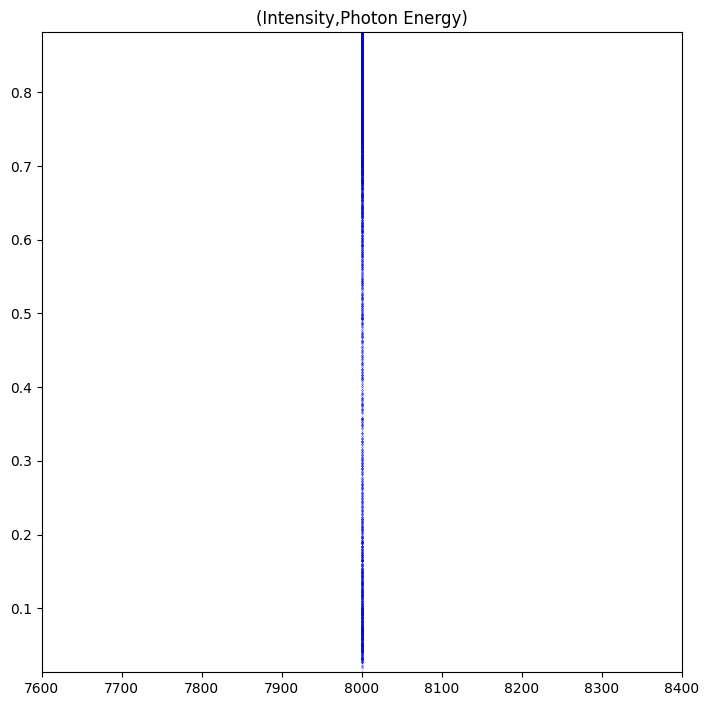

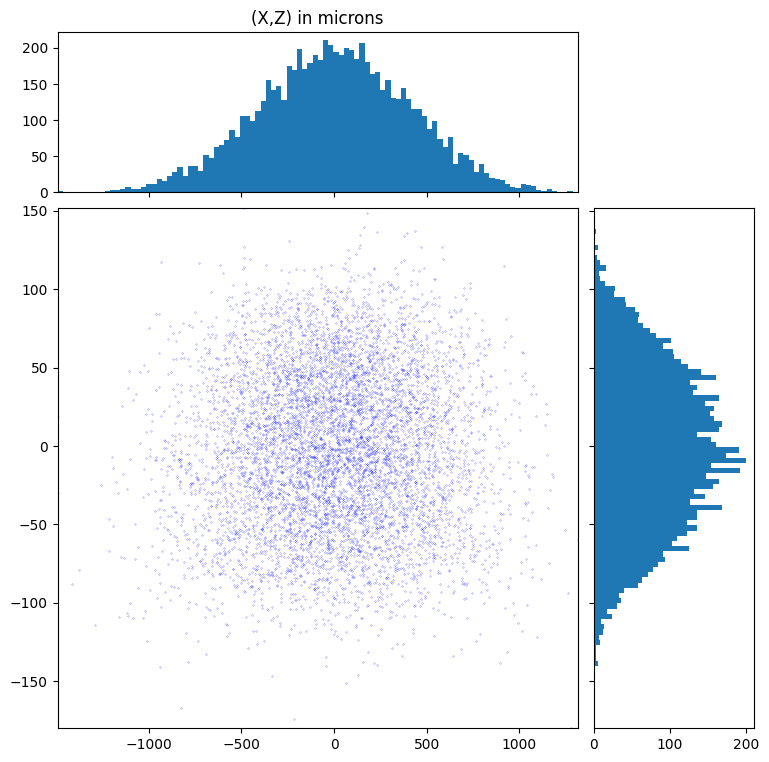

In [2]:
from shadow4.beamline.s4_beamline import S4Beamline

beamline = S4Beamline()

#
#
#
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
light_source = SourceGeometrical(name='Geometrical Source', nrays=10000, seed=0)
light_source.set_spatial_type_gaussian(sigma_h=0.00025,sigma_v=0.000020)
light_source.set_depth_distribution_off()
light_source.set_angular_distribution_gaussian(sigdix=0.000020,sigdiz=0.000020)
light_source.set_energy_distribution_singleline(8000.000000, unit='eV')
light_source.set_polarization(polarization_degree=1.000000, phase_diff=0.000000, coherent_beam=0)
beam = light_source.get_beam()

beamline.set_light_source(light_source)

# optical element number XX
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.25, y_top=0.25)
        
from shadow4.beamline.optical_elements.mirrors.s4_toroid_mirror import S4ToroidMirror
optical_element = S4ToroidMirror(name='M1 Toroidal mirror V-deflecting',boundary_shape=boundary_shape,
    surface_calculation=1,
    min_radius=0.06,  # min_radius = sagittal
    maj_radius=2400,  # maj_radius = tangential
    f_torus=0,
    p_focus=12,q_focus=12,grazing_angle=0.005,
    f_reflec=0,f_refl=0,file_refl='<none>',refraction_index=0.99999+0.001j,
    coating_material='Si',coating_density=2.33,coating_roughness=0)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=12, q=0, angle_radial=1.565796327, angle_azimuthal=0, angle_radial_out=1.565796327)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=1e-09, offset_y=1e-09, offset_z=1e-09, rotation_x=1.74533e-11, rotation_y=1.74533e-11, rotation_z=1.74533e-11)
from shadow4.beamline.optical_elements.mirrors.s4_toroid_mirror import S4ToroidMirrorElement
beamline_element = S4ToroidMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.5, x_right=0.5, y_bottom=-0.000249999, y_top=0.000250001)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='M1 slits V-defining', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.5, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.005, x_right=0.005, y_bottom=-0.005, y_top=0.005)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='differential pump Slits', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=8.5, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
boundary_shape = None

from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystal
optical_element = S4PlaneCrystal(name='DCM1',
    boundary_shape=boundary_shape, material='Si',
    miller_index_h=1, miller_index_k=1, miller_index_l=1,
    f_bragg_a=False, asymmetry_angle=0.0,
    is_thick=1, thickness=0.001,
    f_central=0, f_phot_cent=0, phot_cent=8000.0,
    file_refl='bragg.dat',
    f_ext=0,
    material_constants_library_flag=0, # 0=xraylib,1=dabax,2=preprocessor v1,3=preprocessor v2
    method_efields_management=0, # 0=new in S4; 1=like in S3
    )
from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=3, q=0, angle_radial=1.321032031, angle_azimuthal=0, angle_radial_out=1.321032031)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=1e-09, offset_y=1e-09, offset_z=1e-09, rotation_x=1.74533e-11, rotation_y=1.74533e-11, rotation_z=1.74533e-11)
from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystalElement
beamline_element = S4PlaneCrystalElement(optical_element=optical_element,coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
boundary_shape = None

from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystal
optical_element = S4PlaneCrystal(name='DCM2',
    boundary_shape=boundary_shape, material='Si',
    miller_index_h=1, miller_index_k=1, miller_index_l=1,
    f_bragg_a=False, asymmetry_angle=0.0,
    is_thick=1, thickness=0.001,
    f_central=0, f_phot_cent=0, phot_cent=8000.0,
    file_refl='bragg.dat',
    f_ext=0,
    material_constants_library_flag=0, # 0=xraylib,1=dabax,2=preprocessor v1,3=preprocessor v2
    method_efields_management=0, # 0=new in S4; 1=like in S3
    )
from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.025, q=0, angle_radial=1.321032031, angle_azimuthal=3.141592654, angle_radial_out=1.321032031)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=1e-09, offset_y=1e-09, offset_z=1e-09, rotation_x=1.74533e-11, rotation_y=1.74533e-11, rotation_z=1.74533e-11)
from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystalElement
beamline_element = S4PlaneCrystalElement(optical_element=optical_element,coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.5, x_right=0.5, y_bottom=-0.005, y_top=0.005)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='White beam slits (Harmonic suppressor)', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.075, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.5, x_right=0.5, y_bottom=-0.5, y_top=0.5)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='Generic Beam Screen/Slit/Stopper/Attenuator', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.5, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.152, x_right=0.152, y_bottom=-0.152, y_top=0.152)
   
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
optical_element = S4PlaneMirror(name='hexapod',boundary_shape=boundary_shape,
    f_reflec=0,f_refl=0,file_refl='<none>',refraction_index=0.99999+0.001j,
    coating_material='Si',coating_density=2.33,coating_roughness=0)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=1, q=0, angle_radial=0.7853981634, angle_azimuthal=0, angle_radial_out=0.7853981634)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=1e-09, offset_y=1e-09, offset_z=1e-09, rotation_x=1.74533e-11, rotation_y=1.74533e-11, rotation_z=1.74533e-11)
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
boundary_shape = None

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='Pilatus', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=1, q=1, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)


# test plot
if True:
   from srxraylib.plot.gol import plot_scatter
   plot_scatter(beam.get_photon_energy_eV(nolost=1), beam.get_column(23, nolost=1), title='(Intensity,Photon Energy)', plot_histograms=0)
   plot_scatter(1e6 * beam.get_column(1, nolost=1), 1e6 * beam.get_column(3, nolost=1), title='(X,Z) in microns')

### adding degree of freedom (dof) to the shadow 4 beamline 5.3.1 model


In [4]:
dof_m1_rel_pitch_deg = -0.0000
dof_m1_bending_m = 2400
dof_mono_height_m = 0
dof_mono_angle_rel_angle_deg = 0.00
(dof_hexapod_rel_x_m,dof_hexapod_rel_y_m, dof_hexapod_rel_z_m, 
 dof_hexapod_rel_Rx_deg, dof_hexapod_rel_Ry_deg, dof_hexapod_rel_Rz_deg) = 0, 0, 0, 0, 0, 0

>>>>>> change_reference_system:  True True
>>>>>> change_reference_system:  True True


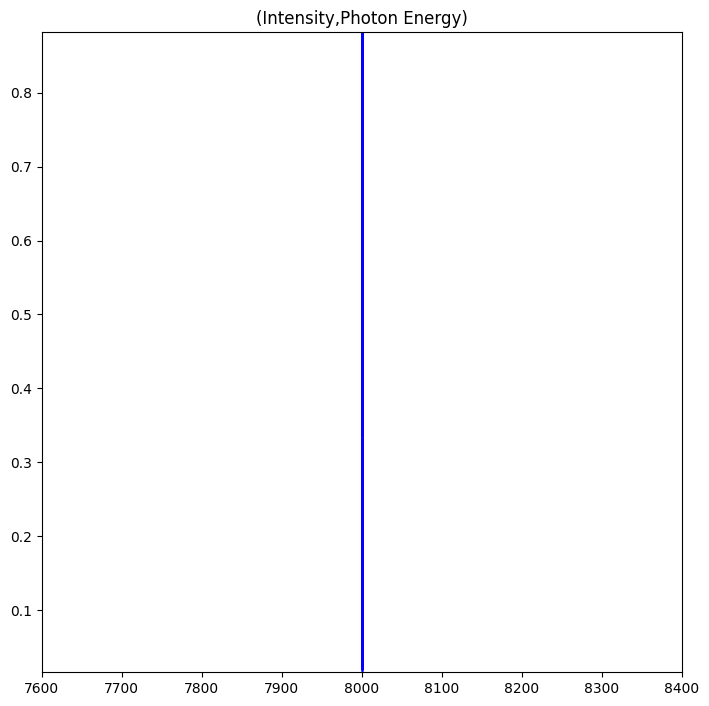

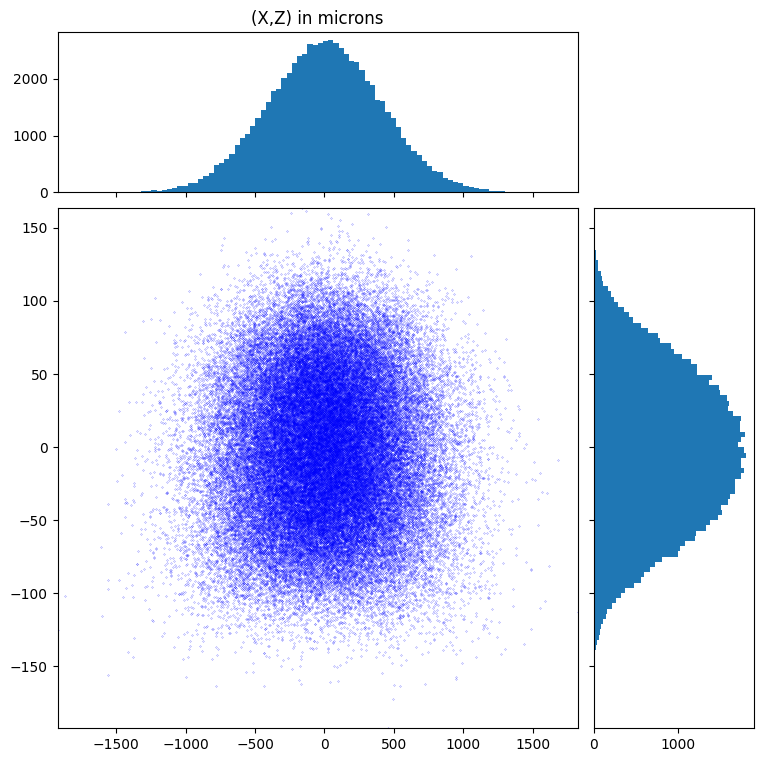

In [5]:
from shadow4.beamline.s4_beamline import S4Beamline

beamline = S4Beamline()

#
#
#
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
light_source = SourceGeometrical(name='Geometrical Source', nrays=100000, seed=0)
light_source.set_spatial_type_gaussian(sigma_h=0.00025,sigma_v=0.000020)
light_source.set_depth_distribution_off()
light_source.set_angular_distribution_gaussian(sigdix=0.000020,sigdiz=0.000020)
light_source.set_energy_distribution_singleline(8000.000000, unit='eV')
light_source.set_polarization(polarization_degree=1.000000, phase_diff=0.000000, coherent_beam=0)
beam = light_source.get_beam()

beamline.set_light_source(light_source)

# M1 toroidal mirror
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.25, y_top=0.25)
        
from shadow4.beamline.optical_elements.mirrors.s4_toroid_mirror import S4ToroidMirror
optical_element = S4ToroidMirror(name='M1 Toroidal mirror V-deflecting',boundary_shape=boundary_shape,
    surface_calculation=1,
    min_radius=0.06,  # min_radius = sagittal
    maj_radius=dof_m1_bending_m,  # maj_radius = tangential
    f_torus=0,
    p_focus=12,q_focus=12,grazing_angle=0.005,
    f_reflec=0,f_refl=0,file_refl='<none>',refraction_index=0.99999+0.001j,
    coating_material='Si',coating_density=2.33,coating_roughness=0)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=12, q=0, angle_radial=1.565796327, angle_azimuthal=0, angle_radial_out=1.565796327)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=1e-09, offset_y=1e-09, offset_z=1e-09, rotation_x=dof_m1_rel_pitch_deg, rotation_y=1.74533e-11, rotation_z=1.74533e-11)
from shadow4.beamline.optical_elements.mirrors.s4_toroid_mirror import S4ToroidMirrorElement
beamline_element = S4ToroidMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# M1 photon slit
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.5, x_right=0.5, y_bottom=-0.000249999, y_top=0.000250001)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='M1 slits V-defining', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.5, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.005, x_right=0.005, y_bottom=-0.005, y_top=0.005)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='differential pump Slits', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=8.5, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# dcm1
boundary_shape = None

from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystal
optical_element = S4PlaneCrystal(name='DCM1',
    boundary_shape=boundary_shape, material='Si',
    miller_index_h=1, miller_index_k=1, miller_index_l=1,
    f_bragg_a=False, asymmetry_angle=0.0,
    is_thick=1, thickness=0.001,
    f_central=0, f_phot_cent=0, phot_cent=8000.0,
    file_refl='bragg.dat',
    f_ext=0,
    material_constants_library_flag=0, # 0=xraylib,1=dabax,2=preprocessor v1,3=preprocessor v2
    method_efields_management=0, # 0=new in S4; 1=like in S3
    )
from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=3, q=0, angle_radial=1.321032031, angle_azimuthal=0, angle_radial_out=1.321032031)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=1e-09, offset_y=1e-09, offset_z=dof_mono_height_m, rotation_x=dof_mono_angle_rel_angle_deg, rotation_y=1.74533e-11, rotation_z=1.74533e-11)
from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystalElement
beamline_element = S4PlaneCrystalElement(optical_element=optical_element,coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# dcm2
boundary_shape = None

from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystal
optical_element = S4PlaneCrystal(name='DCM2',
    boundary_shape=boundary_shape, material='Si',
    miller_index_h=1, miller_index_k=1, miller_index_l=1,
    f_bragg_a=False, asymmetry_angle=0.0,
    is_thick=1, thickness=0.001,
    f_central=0, f_phot_cent=0, phot_cent=8000.0,
    file_refl='bragg.dat',
    f_ext=0,
    material_constants_library_flag=0, # 0=xraylib,1=dabax,2=preprocessor v1,3=preprocessor v2
    method_efields_management=0, # 0=new in S4; 1=like in S3
    )
from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.025, q=0, angle_radial=1.321032031, angle_azimuthal=3.141592654, angle_radial_out=1.321032031)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=1e-09, offset_y=1e-09, offset_z=1e-09, rotation_x=1.74533e-11, rotation_y=1.74533e-11, rotation_z=1.74533e-11)
from shadow4.beamline.optical_elements.crystals.s4_plane_crystal import S4PlaneCrystalElement
beamline_element = S4PlaneCrystalElement(optical_element=optical_element,coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# white beam slits (Harmonic suppressor)
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.5, x_right=0.5, y_bottom=-0.005, y_top=0.005)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='White beam slits (Harmonic suppressor)', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.075, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# beam defining slits
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.5, x_right=0.5, y_bottom=-0.5, y_top=0.5)

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='Generic Beam Screen/Slit/Stopper/Attenuator', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=0.5, q=0, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# hexapod mirror
from syned.beamline.shape import Rectangle
boundary_shape = Rectangle(x_left=-0.152, x_right=0.152, y_bottom=-0.152, y_top=0.152)
   
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirror
optical_element = S4PlaneMirror(name='hexapod',boundary_shape=boundary_shape,
    f_reflec=0,f_refl=0,file_refl='<none>',refraction_index=0.99999+0.001j,
    coating_material='Si',coating_density=2.33,coating_roughness=0)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=1, q=0, angle_radial=0.7853981634, angle_azimuthal=0, angle_radial_out=0.7853981634)
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements
movements = S4BeamlineElementMovements(f_move=1, offset_x=dof_hexapod_rel_x_m, offset_y=dof_hexapod_rel_y_m, offset_z=dof_hexapod_rel_z_m, rotation_x=dof_hexapod_rel_Rx_deg, rotation_y=dof_hexapod_rel_Ry_deg, rotation_z=dof_hexapod_rel_Rz_deg)
from shadow4.beamline.optical_elements.mirrors.s4_plane_mirror import S4PlaneMirrorElement
beamline_element = S4PlaneMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)

# optical element number XX
boundary_shape = None

from shadow4.beamline.optical_elements.absorbers.s4_screen import S4Screen
optical_element = S4Screen(name='Pilatus', boundary_shape=boundary_shape,
    i_abs=0, # 0=No, 1=prerefl file_abs, 2=xraylib, 3=dabax
    i_stop=0, thick=0, file_abs='<specify file name>', material='Au', density=19.3)

from syned.beamline.element_coordinates import ElementCoordinates
coordinates = ElementCoordinates(p=1, q=1, angle_radial=0, angle_azimuthal=0, angle_radial_out=3.141592654)
from shadow4.beamline.optical_elements.absorbers.s4_screen import S4ScreenElement
beamline_element = S4ScreenElement(optical_element=optical_element, coordinates=coordinates, input_beam=beam)

beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)


# test plot
if True:
   from srxraylib.plot.gol import plot_scatter
   plot_scatter(beam.get_photon_energy_eV(nolost=1), beam.get_column(23, nolost=1), title='(Intensity,Photon Energy)', plot_histograms=0)
   plot_scatter(1e6 * beam.get_column(1, nolost=1), 1e6 * beam.get_column(3, nolost=1), title='(X,Z) in microns')

In [6]:
import numpy as np
# plot_scatter(1e6 * beam.get_column(1, nolost=1), 1e6 * beam.get_column(3, nolost=1), title='(X,Z) in microns')
x_m, y_m = beam.get_column(1, nolost=1), beam.get_column(3, nolost=1)
intensity = beam.get_column(23, nolost=1)

camera_length_x_pixel = 1200
camera_length_y_pixel = 1000
camera_pixel_size_m = 2.4e-6
magnification = 0.25

camera_x_m = camera_length_x_pixel * camera_pixel_size_m / magnification
camera_y_m = camera_length_y_pixel * camera_pixel_size_m / magnification

grid_x_m = np.linspace(-camera_x_m/2, camera_x_m/2, camera_length_x_pixel)
grid_y_m = np.linspace(-camera_y_m/2, camera_y_m/2, camera_length_y_pixel)
grid_xx, grid_yy = np.meshgrid(grid_x_m, grid_y_m)

camera_image, xedges, yedges = np.histogram2d(x_m, y_m, bins=[grid_x_m, grid_y_m], weights=intensity)


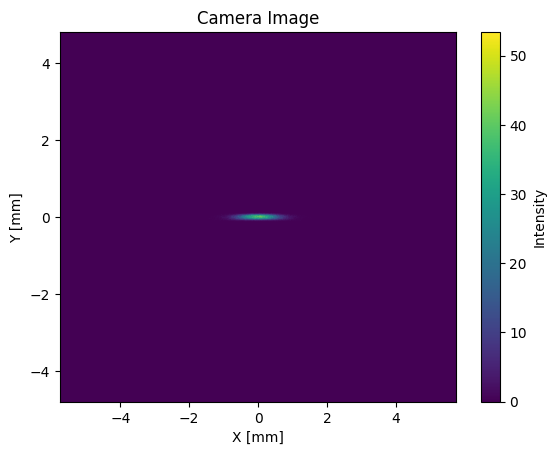

In [7]:
import matplotlib.pyplot as plt
# plot in mm
plt.imshow(camera_image.T, extent=[grid_x_m[0]*1e3, grid_x_m[-1]*1e3, grid_y_m[0]*1e3, grid_y_m[-1]*1e3], origin='lower', aspect='auto')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')
plt.title('Camera Image')
plt.colorbar(label='Intensity')
plt.show()